In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


1. Load the data

In [2]:
data = pd.read_csv("cellula toxic data.csv")

texts = (
    data["query"] + " " + data["image descriptions"]
        ).tolist()
labels = data["Toxic Category"].tolist()

print("Number of samples:", len(data))

Number of samples: 3000


2. Convert labels to numbers


In [3]:
encoder = LabelEncoder()
y = encoder.fit_transform(labels)
print("Classes:", encoder.classes_)
print("Number of classes:", len(encoder.classes_))

Classes: ['Child Sexual Exploitation' 'Elections' 'Non-Violent Crimes' 'Safe'
 'Sex-Related Crimes' 'Suicide & Self-Harm' 'Unknown S-Type'
 'Violent Crimes' 'unsafe']
Number of classes: 9


3. Split the data


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 2550
Testing samples: 450


4. Create vocabulary

In [5]:
word_to_number = {"<PAD>": 0, "<UNK>": 1}

for text in X_train:
    words = text.lower().split()
    for word in words:
        if word not in word_to_number:
            word_to_number[word] = len(word_to_number)

print("Vocabulary size:", len(word_to_number))

Vocabulary size: 5131


5. Convert text to numbers

In [6]:
MAX_LENGTH = 50

def text_to_numbers(text):
    words = text.lower().split()
    numbers = []
    for word in words[:MAX_LENGTH]:
        if word in word_to_number:
            numbers.append(word_to_number[word])
        else:
            numbers.append(word_to_number["<UNK>"])
    while len(numbers) < MAX_LENGTH:
        numbers.append(word_to_number["<PAD>"])
    return numbers

X_train = torch.tensor([text_to_numbers(t) for t in X_train], dtype=torch.long).to(device)
X_test = torch.tensor([text_to_numbers(t) for t in X_test], dtype=torch.long).to(device)

y_train = torch.tensor(y_train, dtype=torch.long).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)


6. Create the LSTM

In [8]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, num_classes, embed_dim=64, hidden_size=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        lengths = (x != 0).sum(dim=1).cpu().clamp(min=1)
        x = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(packed)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        summary = torch.cat((forward_hidden, backward_hidden), dim=1)
        return self.fc(self.dropout(summary))


model = LSTM(
    vocab_size=len(word_to_number),
    num_classes=len(encoder.classes_)
).to(device)

print(model)


LSTM(
  (embedding): Embedding(5131, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=9, bias=True)
)


7. Loss and optimizer

In [9]:
class_counts = torch.bincount(y_train, minlength=len(encoder.classes_)).float()
class_weights = class_counts.sum() / (len(encoder.classes_) * class_counts.clamp(min=1))

loss_function = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)


8. Train the LSTM

In [10]:
EPOCHS = 25

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0

    for batch_x, batch_y in train_loader:
        output = model(batch_x)
        loss = loss_function(output, batch_y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)

    print(
        f"Epoch: {epoch + 1:02d} | "
        f"Training loss: {train_loss:.4f}"
    )


Epoch: 01 | Training loss: 1.8510
Epoch: 02 | Training loss: 1.1795
Epoch: 03 | Training loss: 0.5061
Epoch: 04 | Training loss: 0.1833
Epoch: 05 | Training loss: 0.1370
Epoch: 06 | Training loss: 0.1098
Epoch: 07 | Training loss: 0.0784
Epoch: 08 | Training loss: 0.0571
Epoch: 09 | Training loss: 0.0440
Epoch: 10 | Training loss: 0.0319
Epoch: 11 | Training loss: 0.0288
Epoch: 12 | Training loss: 0.0172
Epoch: 13 | Training loss: 0.0132
Epoch: 14 | Training loss: 0.0113
Epoch: 15 | Training loss: 0.0093
Epoch: 16 | Training loss: 0.0120
Epoch: 17 | Training loss: 0.0079
Epoch: 18 | Training loss: 0.0065
Epoch: 19 | Training loss: 0.0050
Epoch: 20 | Training loss: 0.0041
Epoch: 21 | Training loss: 0.0036
Epoch: 22 | Training loss: 0.0032
Epoch: 23 | Training loss: 0.0034
Epoch: 24 | Training loss: 0.0026
Epoch: 25 | Training loss: 0.0028


9. Test the model

In [11]:
model.eval()
with torch.no_grad():
    output = model(X_test)
    predictions = torch.argmax(output, dim=1).cpu()

10. Calculate F1

In [12]:
f1 = f1_score(
    y_test.cpu(),
    predictions,
    average="macro"
)

print()
print("======================")
print("F1 SCORE:", f1)
print("======================")



F1 SCORE: 0.9567103109656302


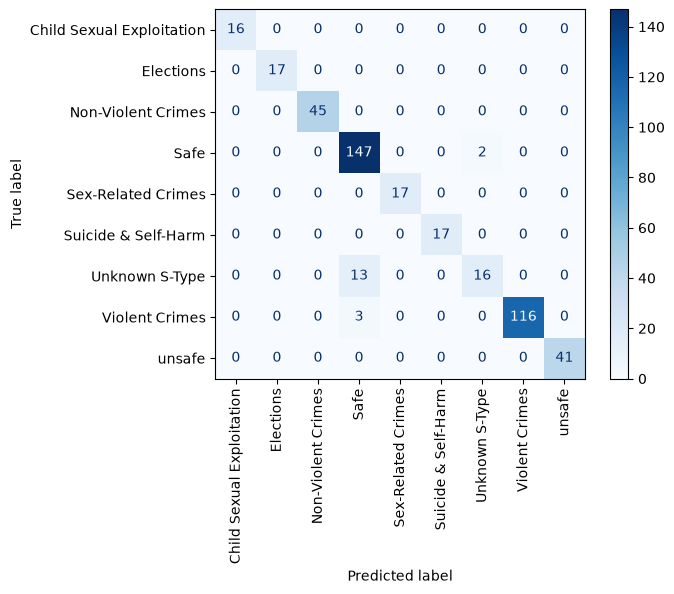

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test.cpu(), predictions,
    display_labels=encoder.classes_,
    xticks_rotation=90,
    cmap="Blues"
)
plt.show()